In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pytest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

#imported ALL libraries in this cell even the ones used in the last cells



In [ ]:
#loading dataset
df = pd.read_csv('E:/Downloads/iris.data.csv')

In [ ]:
# rename the dataframe columns to meaningful feature names and the target class

df.columns = ['sepal length', 'sepal width', 'petal length', 'petal width', 'species']
df.head()

,sepal length,sepal width,petal length,petal width,species
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


In [ ]:
# generate summary statistics for each feature (mean, std, min, max, quartiles)
# helps identify potential data scaling needs and outliers before modeling
print (df.describe())


# check for missing values in each column
# logistic regression in scikitlearn cannot handle nulls so we confirm dataset completeness
df.isnull().sum()

       sepal length  sepal width  petal length  petal width
count    149.000000   149.000000    149.000000   149.000000
mean       5.848322     3.051007      3.774497     1.205369
std        0.828594     0.433499      1.759651     0.761292
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.400000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


sepal length    0
sepal width     0
petal length    0
petal width     0
species         0
dtype: int64

In [ ]:
#check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 3


In [ ]:

df.drop_duplicates(inplace=True)
#check for duplicates after dropping
duplicates = df.duplicated().sum()
print (f"Number of duplicate rows after dropping: {duplicates}")


Number of duplicate rows after dropping: 0


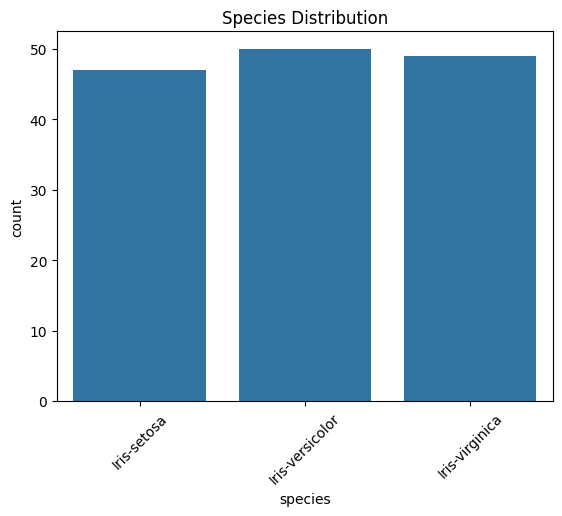

In [ ]:
# creating bar plot to visualize the count of samples in each species category
sns.countplot(x='species', data=df)
plt.title("Species Distribution")
plt.xticks(rotation=45) #for better readability of x-axis labels
plt.show()

#graph depicts equal representation of each species in the dataset

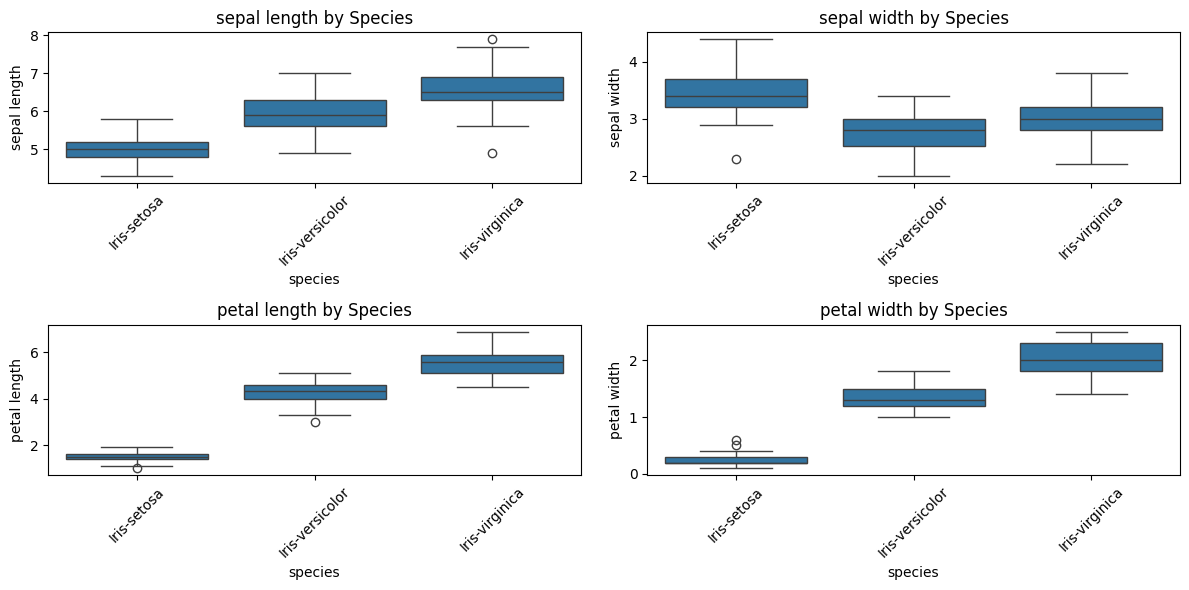

In [ ]:
#defining features columns to plot
features = ['sepal length', 'sepal width', 'petal length', 'petal width']

#setting overall figure size for the box plots
plt.figure(figsize=(12, 6))

#looping thru each feature and plot a boxplot segmented by species
for i in range(len(features)):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='species', y=features[i], data=df)
    plt.title(f'{features[i]} by Species')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

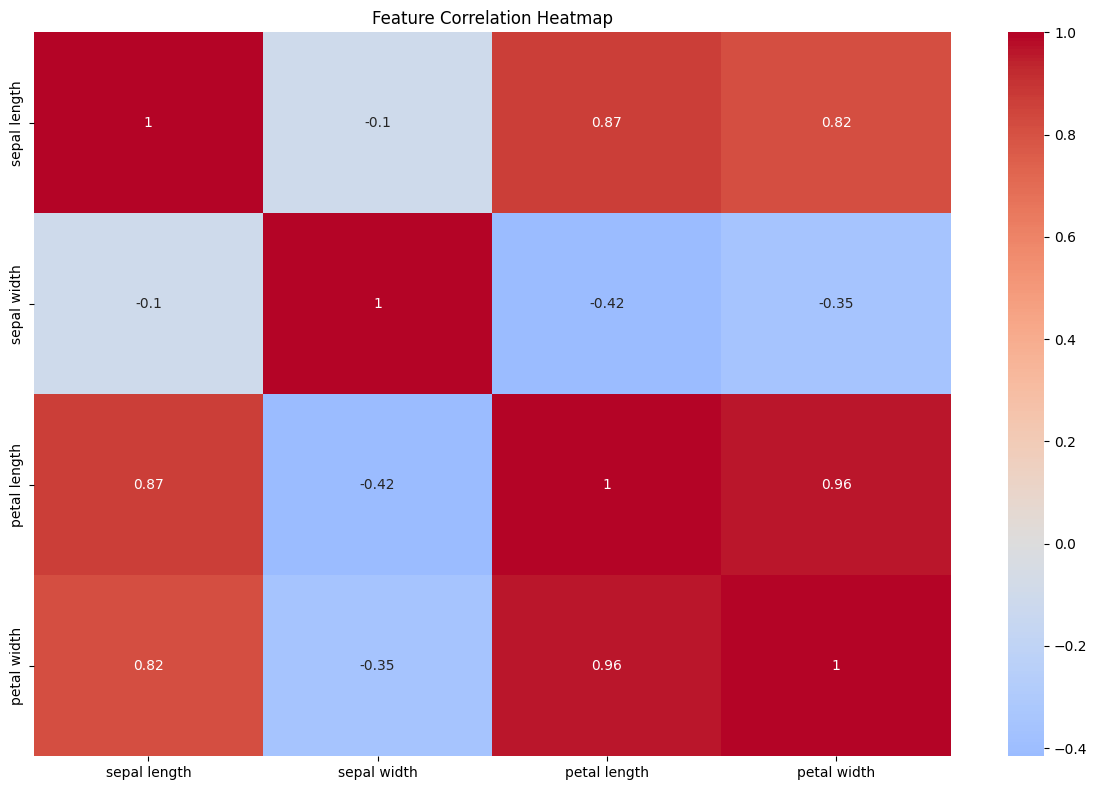

In [ ]:
# Create correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop('species', axis=1).corr(), 
            annot=True,
            cmap='coolwarm',
            center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
#calculate and visualize VIF scores
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) 
                       for i in range(df.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

#calculating VIF scores
X = df.drop('species', axis=1)
print("\nInitial VIF Scores:")
print(calculate_vif(X))

#function to iteratively remove high VIF features
def remove_high_vif(df, threshold=5):
    features = df.columns
    vif_data = calculate_vif(df)
    
    while any(vif_data['VIF'] > threshold):
        feature_to_drop = vif_data.iloc[0]['Feature']
        print(f"Dropping {feature_to_drop} with VIF = {vif_data.iloc[0]['VIF']:.2f}")
        features = features.drop(feature_to_drop)
        vif_data = calculate_vif(df[features])
    
    return features

#get features to keep
X = df.drop('species', axis=1)
selected_features = remove_high_vif(X, threshold=5)
print("\nFinal features after VIF selection:")
print(selected_features.tolist())
print ('selected features:', selected_features)


Initial VIF Scores:
        Feature         VIF
0  sepal length  260.469265
2  petal length  172.005128
1   sepal width   94.775033
3   petal width   55.196090
Dropping sepal length with VIF = 260.47
Dropping petal length with VIF = 61.40

Final features after VIF selection:
['sepal width', 'petal width']
selected features: Index(['sepal width', 'petal width'], dtype='object')


In [ ]:
#encoding target variable'species' into numeric labels (0, 1, 2)
#required because machine learning models cannot work with text labels
le = LabelEncoder()
y = le.fit_transform(df['species'])
x = df[selected_features] #select only the features that passed VIF threshold

#splitting the dataset into training and testing sets 20% for testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#scaling the features
scaler = StandardScaler() #all features contribute equally to distance calculations in models
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [ ]:
#training  logistic regression model
model = LogisticRegression(random_state=42, multi_class='multinomial')#appropriate for multi-class classification
model.fit( x_train_scaled, y_train)

#predicting on test set
y_pred = model.predict(x_test_scaled)


e:\OneDrive\Documents\coding\MLInternship\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:

#evaluating model performance
# Create DataFrame with actual and predicted values
comparison_df = pd.DataFrame({
    'Actual Species': le.inverse_transform(y_test),
    'Predicted Species': le.inverse_transform(y_pred)
})

# Add a column to show if prediction was correct
comparison_df['Correct Prediction'] = comparison_df['Actual Species'] == comparison_df['Predicted Species']

# Display the comparison
print("\nPrediction Comparison:")
print("-" * 60)
print(comparison_df)
print("\nAccuracy:", (comparison_df['Correct Prediction'].value_counts()[True] / len(comparison_df)) * 100, "%")


Prediction Comparison:
------------------------------------------------------------
     Actual Species Predicted Species  Correct Prediction
0       Iris-setosa       Iris-setosa                True
1    Iris-virginica    Iris-virginica                True
2       Iris-setosa       Iris-setosa                True
3       Iris-setosa       Iris-setosa                True
4       Iris-setosa       Iris-setosa                True
5    Iris-virginica    Iris-virginica                True
6       Iris-setosa       Iris-setosa                True
7   Iris-versicolor   Iris-versicolor                True
8   Iris-versicolor   Iris-versicolor                True
9       Iris-setosa       Iris-setosa                True
10      Iris-setosa       Iris-setosa                True
11   Iris-virginica    Iris-virginica                True
12   Iris-virginica    Iris-virginica                True
13  Iris-versicolor   Iris-versicolor                True
14   Iris-virginica    Iris-virginica        

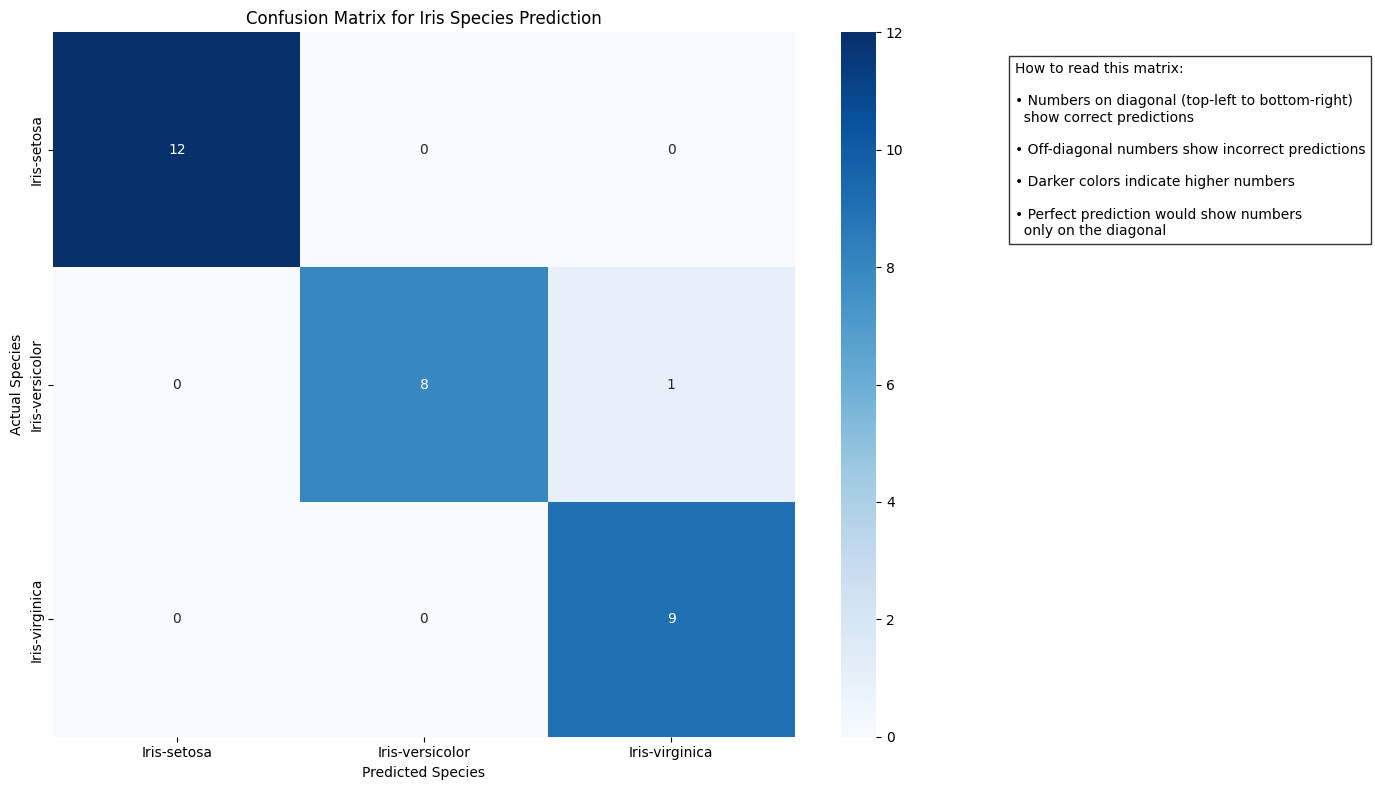


Detailed Classification Report:
------------------------------------------------------------
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.90      1.00      0.95         9

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.96        30
   weighted avg       0.97      0.97      0.97        30



In [ ]:
# Create and plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)

# Create confusion matrix heatmap with annotations
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('Confusion Matrix for Iris Species Prediction')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')

# Add text explanation
plt.figtext(1.02, 0.7, 
            'How to read this matrix:\n\n' + 
            '• Numbers on diagonal (top-left to bottom-right)\n  show correct predictions\n\n' +
            '• Off-diagonal numbers show incorrect predictions\n\n' +
            '• Darker colors indicate higher numbers\n\n' +
            '• Perfect prediction would show numbers\n  only on the diagonal',
            bbox=dict(facecolor='white', alpha=0.8),
            fontsize=10)

plt.tight_layout()
plt.show()

# Print classification report for detailed metrics
print("\nDetailed Classification Report:")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=le.classes_))